# **Análisis de resultados tras 100 simulaciones**

Este cuaderno tiene como objetivo analizar los resultados generados por el modelo `CardioModel`. Mediante simulaciones de Montecarlo (100 iteraciones), evaluaremos la evolución del colesterol LDL, el cumplimiento nutricional y la tasa de adherencia de los pacientes virtuales bajo dos intervenciones dietéticas distintas: la **Dieta Mediterránea** y la **Dieta Baja en Grasas**.

A continuación, se importan las librerías necesarias y se configuran las rutas para acceder a las variables y clases del modelo:

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import sys
import os

# Configuración de ruta para encontrar variables y modelo
sys.path.append(os.path.abspath('..'))
from model.cardioModel import CardioModel
from configuration import settings

<IPython.core.display.Javascript object>

Could not import SolaraViz. If you need it, install with 'pip install --pre mesa[viz]'


Dado que el modelo incluye variables estocásticas (ruido estadístico en la ingesta, probabilidad de abandono, etc.), los resultados de una única simulación no son estadísticamente robustos. 

Para solucionar esto, aplicamos el método **Montecarlo**, ejecutando el modelo múltiples veces para obtener una muestra representativa del comportamiento poblacional. Definimos entonces un total de 100 simulaciones independientes: cada iteración instanciará 212 pacientes completamente nuevos que irán registrando datos de ingesta y de evolución de biomarcadores a lo largo de 12 semanas. Finalmente, se concatenarán todos los datos en un único *DataFrame* que contendrá el historial completo de los 21200 pacientes simulados.

In [2]:
# 1. Configuración de la simulación (100 iteraciones)
NUM_SIMULACIONES = 100
SEMANAS = 12

# Lista vacía para almacenar resultados de cada simulación
resultados = []

# Mostrar datos con solo 2 decimales
pd.options.display.float_format = '{:.2f}'.format

# 2. Bucle principal de simulaciones
print(f"Iniciando {NUM_SIMULACIONES} simulaciones independientes de ingesta nutricional y evolución de biomarcadores...")

for sim in tqdm(range(NUM_SIMULACIONES)):
    modelo = CardioModel(num_pacientes=settings.NUM_PACIENTES)
    
    # Ejecutar 12 semanas
    for _ in range(SEMANAS):
        modelo.step()
        
    # Extraer los datos de la simulación
    df_simulacion = modelo.datacollector.get_agent_vars_dataframe()
    
    # Añadir una columna para saber a qué simulación pertenecen estos datos
    df_simulacion['Num_Simulacion'] = sim
    
    # Guardar en lista creada previamente
    resultados.append(df_simulacion)

# 3. Finalmente, unir todas las simulaciones en un único DataFrame
df = pd.concat(resultados)
df = df.reset_index() # Reseteamos el índice para separar (Step, AgentID) en columnas

# Mostramos las primeras filas
df.head()

Iniciando 100 simulaciones independientes de ingesta nutricional y evolución de biomarcadores...


 ... (more hidden) ...


,Step,AgentID,Grupo,Estado,Calorías,Proteínas,Carbohidratos,Grasa_Total_g,Grasa_Sat_g,Grasa_Mono_g,Grasa_Poli_g,Colesterol_LDL,Num_Simulacion
0,0,0,Mediterránea,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.69,0
1,0,1,Mediterránea,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.56,0
2,0,2,Mediterránea,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.50,0
3,0,3,Mediterránea,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.60,0
4,0,4,Mediterránea,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.30,0


Una vez tenemos el resultado de las 100 simulaciones, pasamos a hacer un breve análisis sobre los resultados obtenidos.

### **1. Tasas de participación y abandono de pacientes**

En primer lugar, para comprobar la validez de la simulación, vamos a comprobar que la distribución de pacientes y tasa de abandonos por dieta de los agentes coinciden con los datos reales del estudio.

Para ello, vamos a evaluar dos factores fundamentales promediando los resultados de las 100 simulaciones al finalizar la Semana 12:
1. **Población Inicial:** Verificamos que ambos grupos parten con la muestra de pacientes correcta (102 pacientes para la Dieta Mediterránea y 110 para la Dieta Baja en Grasas).
2. **Tasa de abandono:** Debemos comprobar que la dieta baja en grasas genera una mayor tasa de abandono (≈26%) que la mediterránea (≈14%).

Para ilustrar los resultados, empleamos un **gráfico de barras apiladas**. La base principal de cada barra representa el número de pacientes que lograron finalizar la dieta a los 3 meses, mientras que la sección superior cuantifica el volumen y porcentaje de pacientes que abandonaron la dieta.

In [3]:
# 1. Extraer los datos de la última semana
df_semana_12 = df[df['Step'] == 12]

# 2. Calcular medias de activos y abandonos a lo largo de las 100 simulaciones
conteos = df_semana_12.groupby(['Num_Simulacion', 'Grupo', 'Estado']).size().unstack(fill_value=0)
# Sacamos la media de esas 100 simulaciones
media_estados = conteos.groupby('Grupo').mean().round(0).astype(int)
display(media_estados)

# 3. Extraemos los valores para las gráficas
# Dieta mediterránea
activos_med = media_estados.loc['Mediterránea', 'ACTIVO']
abandono_med = media_estados.loc['Mediterránea', 'ABANDONO']
total_med = activos_med + abandono_med
pct_abandono_med = (abandono_med / total_med) * 100

# Dieta baja en grasas
activos_lf = media_estados.loc['Baja en Grasas', 'ACTIVO']
abandono_lf = media_estados.loc['Baja en Grasas', 'ABANDONO']
total_lf = activos_lf + abandono_lf
pct_abandono_lf = (abandono_lf / total_lf) * 100

Estado,ABANDONO,ACTIVO
Grupo,,
Baja en Grasas,29,81
Mediterránea,14,88


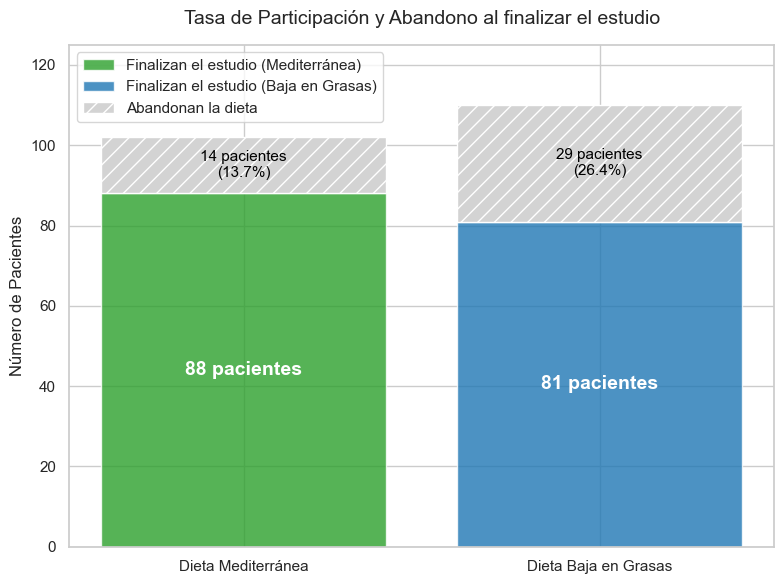

In [4]:
# 4. Dibujar el gráfico de barras apiladas
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(8, 6))

# Barras base (Pacientes Activos)
ax.bar('Dieta Mediterránea', activos_med, label='Finalizan el estudio (Mediterránea)', color='#2ca02c', alpha=0.8)
ax.bar('Dieta Baja en Grasas', activos_lf, label='Finalizan el estudio (Baja en Grasas)', color='#1f77b4', alpha=0.8)

# Barras superiores (Abandonos) --> Comparten estilo
grupos = ['Dieta Mediterránea', 'Dieta Baja en Grasas']
activos = [activos_med, activos_lf]
abandonos = [abandono_med, abandono_lf]
ax.bar(grupos, abandonos, bottom=activos, label='Abandonan la dieta', color='#d3d3d3', hatch='//')

# Añadir las etiquetas de texto dentro de las barras
ax.text(0, activos_med / 2, f"{activos_med} pacientes", ha='center', va='center', color='white', fontweight='bold', fontsize=14)
ax.text(0, activos_med + (abandono_med / 2), f"{abandono_med} pacientes\n({pct_abandono_med:.1f}%)", ha='center', va='center', color='black', fontsize=11)

ax.text(1, activos_lf / 2, f"{activos_lf} pacientes", ha='center', va='center', color='white', fontweight='bold', fontsize=14)
ax.text(1, activos_lf + (abandono_lf / 2), f"{abandono_lf} pacientes\n({pct_abandono_lf:.1f}%)", ha='center', va='center', color='black', fontsize=11)

# Títulos y etiquetas
plt.title('Tasa de Participación y Abandono al finalizar el estudio', fontsize=14, pad=15)
plt.ylabel('Número de Pacientes', fontsize=12)
plt.ylim(0, 125) # Un poco de margen superior
plt.legend(loc='upper left', frameon=True)

plt.tight_layout()
plt.show()

### **2. Validación de la ingesta nutricional de pacientes**

A continuación, se comprueba que los pacientes han cumplido con la dieta estipulada. El objetivo es analizar el reparto de macronutrientes durante las 12 semanas en aquellos pacientes que han cumplido con la dieta hasta el final.

Para ello, utilizaremos unos gráficos tipo **Pie Chart** en los que se represente la cantidad calórica media ingerida en cada dieta, además del porcentaje de energía que supone eso para cada macronutriente. Para el cálculo se aplican los factores de conversión de Atwater (4 kcal/g para proteínas e hidratos de carbono y 9 kcal/g para las grasas).

In [5]:
# 1. Identificar a los pacientes "ACTIVOS" tras la última semana
# Identificadores únicos combinando su AgentId y Num_Simulacion
activos = df_semana_12[df_semana_12['Estado'] == 'ACTIVO'][['Num_Simulacion', 'AgentID']]

# 2. Guardar el historial COMPLETO de estos pacientes
# Cruzar datos del df principal con la lista de pacientes activos
df_historial_activos = pd.merge(df, activos, on=['Num_Simulacion', 'AgentID'])

# 3. Calcular la media de todas las semanas para cada grupo
cols_nutricion = ['Calorías', 'Proteínas', 'Carbohidratos', 'Grasa_Sat_g', 'Grasa_Mono_g', 'Grasa_Poli_g']
medias_nutricion = df_historial_activos.groupby('Grupo')[cols_nutricion].mean()
medias_nutricion

,Calorías,Proteínas,Carbohidratos,Grasa_Sat_g,Grasa_Mono_g,Grasa_Poli_g
Grupo,,,,,,
Baja en Grasas,1621.82,86.61,181.90,20.79,27.32,12.75
Mediterránea,1576.66,77.59,181.15,19.25,29.82,11.11


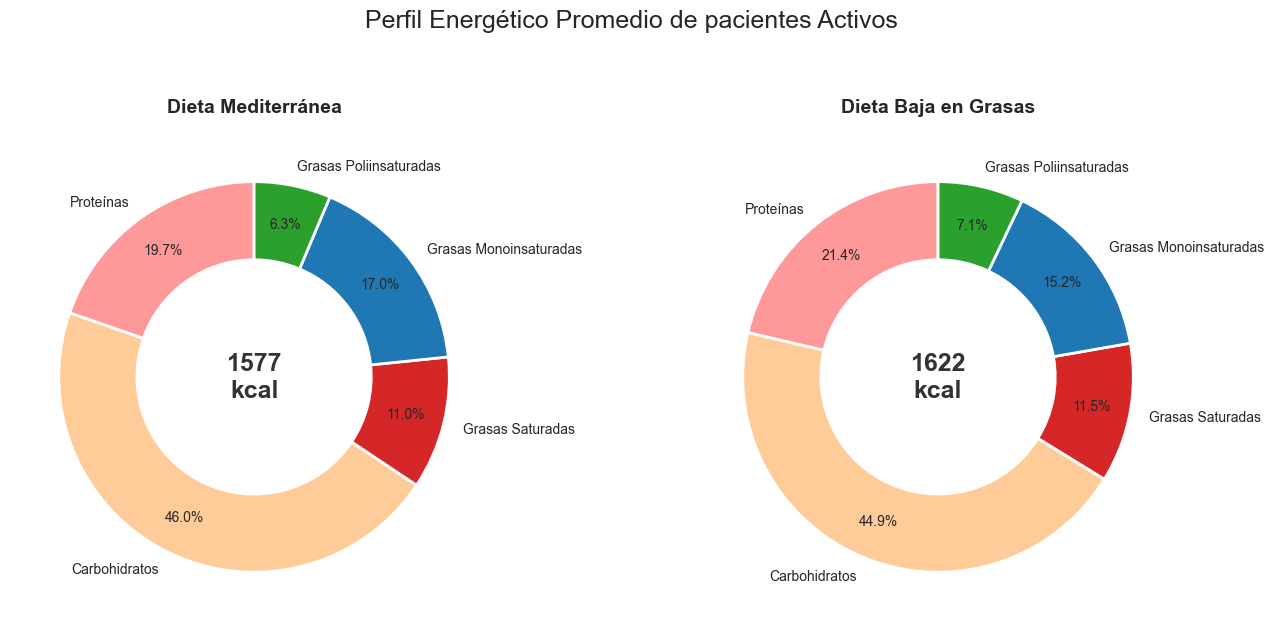

In [6]:
# 4. Dibujar Pie Chart
sns.set_theme(style="white")
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
grupos = ['Mediterránea', 'Baja en Grasas']
colores = ['#ff9999', '#ffcc99', '#d62728', '#1f77b4', '#2ca02c']
etiquetas = ['Proteínas', 'Carbohidratos', 'Grasas Saturadas', 'Grasas Monoinsaturadas', 'Grasas Poliinsaturadas']

for i, grupo in enumerate(grupos):
    # Primero extraemos los gramos
    calorias = medias_nutricion.loc[grupo, 'Calorías']
    prot_g = medias_nutricion.loc[grupo, 'Proteínas']
    carb_g = medias_nutricion.loc[grupo, 'Carbohidratos']
    sat_g = medias_nutricion.loc[grupo, 'Grasa_Sat_g']
    mono_g = medias_nutricion.loc[grupo, 'Grasa_Mono_g']
    poli_g = medias_nutricion.loc[grupo, 'Grasa_Poli_g']
    
    # Convertir gramos a kcal
    g_to_kcal = [prot_g * 4, carb_g * 4, sat_g * 9, mono_g * 9, poli_g * 9]
    
    # Dibujar rosco con macronutrientes
    wedges, texts, autotexts = axes[i].pie(
        g_to_kcal, labels=etiquetas, autopct='%1.1f%%',
        startangle=90, colors=colores, pctdistance=0.80,
        wedgeprops=dict(width=0.4, edgecolor='white', linewidth=2),
        textprops={'fontsize': 10}
    )
    
    # Calorias en el centro
    axes[i].text(0, 0, f"{calorias:.0f}\nkcal", ha='center', va='center', fontsize=18, fontweight='bold', color='#333333')
    axes[i].set_title(f"Dieta {grupo}", fontsize=14, fontweight='bold', pad=15)

plt.suptitle('Perfil Energético Promedio de pacientes Activos', fontsize=18, y=1.05)
plt.tight_layout()
plt.show()

### **3. Evolución del colesterol LDL a lo largo de la intervención**

En este punto buscamos analizar el impacto que tienen ambas dietas sobre el colesterol LDL de los pacientes a lo largo de las 12 semanas de intervención.

Se espera observar una curva de comportamiento asintótico, donde la reducción es mayor durante las primeras semanas y tiende a estabilizarse una vez que el paciente alcanza un nuevo estado de equilibrio bajo la nueva dieta (últimas semanas).

Para ello, utilizamos un gráfico de líneas con **Intervalos de Confianza (95%)**, calculados a partir de las 100 simulaciones, para garantizar que las diferencias observadas sean robustas y no producto del ruido estocástico del modelo.

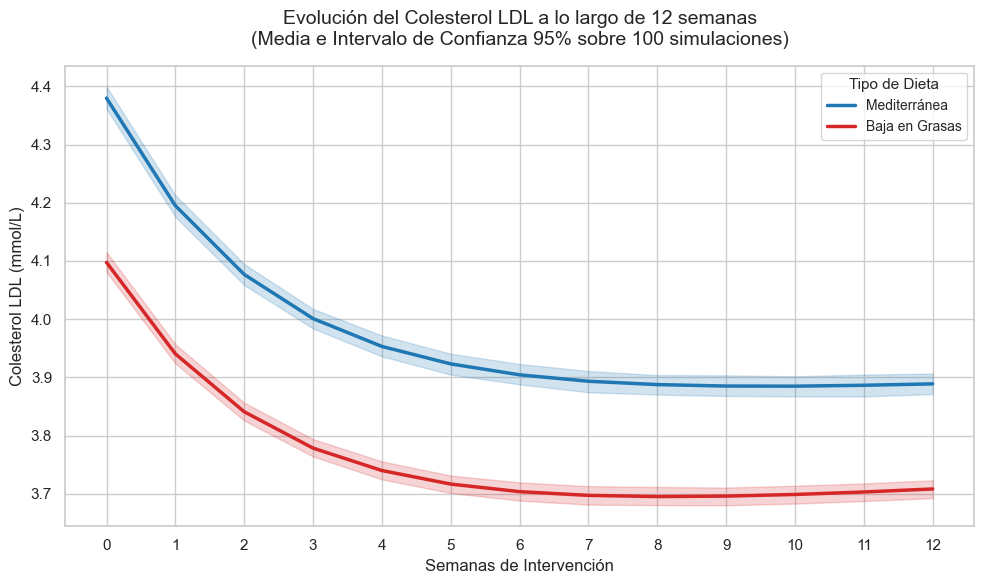

In [7]:
# Dibujar gráfico de líneas con Intervalos de Confianza al 95%
# Configuración del estilo
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Crear gráfica de evolución temporal
grafica = sns.lineplot(
    data=df, 
    x='Step', 
    y='Colesterol_LDL', 
    hue='Grupo', 
    palette=['#1f77b4', '#d62728'],
    linewidth=2.5
)

# Título y etiquetas
plt.title('Evolución del Colesterol LDL a lo largo de 12 semanas\n(Media e Intervalo de Confianza 95% sobre 100 simulaciones)', fontsize=14, pad=15)
plt.xlabel('Semanas de Intervención', fontsize=12)
plt.ylabel('Colesterol LDL (mmol/L)', fontsize=12)
plt.xticks(range(0, 13))
plt.legend(title='Tipo de Dieta', title_fontsize='11', fontsize='10')
plt.tight_layout()
plt.show()